# Klasifikasi dan LDA

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Crawling PTA

In [3]:
import pandas as pd

# Baca file CSV
df = pd.read_csv("/content/drive/MyDrive/PPW/pta_fatek_3halaman.csv")

# Tampilkan informasi total entri
print(f"📊 Total entri: {len(df)}")
print("✅ Data berhasil diambil dari 3 halaman tiap prodi Fakultas Teknik.\n")

# Tampilkan tabel rapih
display(df)


📊 Total entri: 135
✅ Data berhasil diambil dari 3 halaman tiap prodi Fakultas Teknik.



,penulis,judul,pembimbing_pertama,pembimbing_kedua,abstrak,prodi
0,A.Ubaidillah S.Kom,PERANCANGAN DAN IMPLEMENTASI SISTEM DATABASE \...,Budi Setyono M.T,NaN,Sistem informasi akademik (SIAKAD) merupaka...,Teknik Informatika
1,"M. Basith Ardianto,",APLIKASI KONTROL DAN MONITORING JARINGAN KOMPU...,"Drs. Budi Soesilo, MT",NaN,Berjalannya koneksi jaringan komputer dengan l...,Teknik Informatika
2,"Akhmad Suyandi, S.Kom",RANCANG BANGUN APLIKASI PROXY SERVER UNTUK\r\n...,"Drs. Budi Soesilo, M.T",NaN,Web server adalah sebuah perangkat lunak serve...,Teknik Informatika
3,Heri Supriyanto,SISTEM PENDUKUNG KEPUTUSAN OPTIMASI PENJADWALA...,"Mulaab, S.Si., M.Kom",NaN,Penjadwalan kuliah di Perguruan Tinggi me...,Teknik Informatika
4,Septian Rahman Hakim,SISTEM AUGMENTED REALITY ANIMASI BENDA BERGERA...,"Arik Kurniawati, S.Kom., M.T.",NaN,Seiring perkembangan teknologi yang ada diduni...,Teknik Informatika
...,...,...,...,...,...,...
130,DEWI AMALIYA ULFA,Pengaruh Penerapan Pembelajaran Tematik Integr...,"Mujtahidin, S.Pd., M.Pd",NaN,Penelitian ini bertujuan untuk mengetahui peng...,Mekatronika
131,RIZKA AINUN JARIYAH,Pengaruh Metode Pembelajaran Bermain Peran (Ro...,"Eva Ari Wahyuni, S.Pd., M.Si",NaN,Penelitian ini bertujuan untuk mengetahui peng...,Mekatronika
132,LAELA ROKHMATUL KAROMAH,PENGGUNAAN MEDIA PEMBELAJARAN KOTAK CERITA BER...,"Sulaiman, S.Pd., M.Pd",NaN,Di lapangan pada umumnya siswa masih belum mam...,Mekatronika
133,Yuliana,Pengaruh Penggunaan Metode Demonstrasi Terhada...,"Eva Ari Wahyuni, S.Pd., M.Si",NaN,Penelitian “Pengaruh Penggunaan Metode Demonst...,Mekatronika


## Link keluar

In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

def crawl_links_teknik(pages):
    data = []
    no = 1

    for page in pages:
        try:
            response = requests.get(page)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, 'html.parser')

            # Ambil semua link
            links = soup.find_all('a', href=True)
            for link in links:
                href = link['href']
                teks = link.get_text(strip=True)

                # Filter hanya link keluar (mulai dengan http & bukan link internal teknik.trunojoyo.ac.id)
                if href.startswith("http") and "teknik.trunojoyo.ac.id" not in href:
                    data.append({
                        "No": no,
                        "Page": page,
                        "Link Keluar": href,
                        "Teks": teks if teks else "-"
                    })
                    no += 1

        except requests.exceptions.RequestException as e:
            print(f"Gagal mengakses {page}: {e}")

    # Buat DataFrame
    df = pd.DataFrame(data)

    print("\n🔗 Daftar Link Keluar Fakultas Teknik:")
    print(df.to_string(index=False))

    # Simpan hasil ke CSV
    df.to_csv("link_keluar_fakultas_teknik.csv", index=False, encoding="utf-8-sig")
    print("\n✅ Data link keluar berhasil disimpan ke link_keluar_fakultas_teknik.csv")

    return df


# Daftar halaman Fakultas Teknik yang ingin diambil link keluarnya
pages_to_crawl = [
    "https://teknik.trunojoyo.ac.id/",
    "https://teknik.trunojoyo.ac.id/sekilas/",
    "https://teknik.trunojoyo.ac.id/berita/",
    "https://teknik.trunojoyo.ac.id/prodi/",
]

# Jalankan
crawl_links_teknik(pages_to_crawl)

Gagal mengakses https://teknik.trunojoyo.ac.id/berita/: 404 Client Error: Not Found for url: https://teknik.trunojoyo.ac.id/berita/
Gagal mengakses https://teknik.trunojoyo.ac.id/prodi/: 404 Client Error: Not Found for url: https://teknik.trunojoyo.ac.id/prodi/

🔗 Daftar Link Keluar Fakultas Teknik:
 No                                    Page                                                                           Link Keluar                                    Teks
  1         https://teknik.trunojoyo.ac.id/                                               https://fttrunojoyo.perpustakaan.co.id/                      Ruang Baca Digital
  2         https://teknik.trunojoyo.ac.id/ https://drive.google.com/file/d/13vrMWMRLc51yaZPqJw_wBPAgRqiH0315/view?usp=drive_link                         Teknik Industri
  3         https://teknik.trunojoyo.ac.id/   https://drive.google.com/file/d/1p0IjDah2BT7MSg4DPSarLJhbYSVP8lOx/view?usp=drivesdk                            Teknik Mesin
  4         https:/

,No,Page,Link Keluar,Teks
0,1,https://teknik.trunojoyo.ac.id/,https://fttrunojoyo.perpustakaan.co.id/,Ruang Baca Digital
1,2,https://teknik.trunojoyo.ac.id/,https://drive.google.com/file/d/13vrMWMRLc51ya...,Teknik Industri
2,3,https://teknik.trunojoyo.ac.id/,https://drive.google.com/file/d/1p0IjDah2BT7MS...,Teknik Mesin
3,4,https://teknik.trunojoyo.ac.id/,https://drive.google.com/file/d/1xThmCp00FGmAW...,Teknik Informatika
4,5,https://teknik.trunojoyo.ac.id/,https://drive.google.com/file/d/1dv65FxClUVDwu...,Sistem Informasi
...,...,...,...,...
127,128,https://teknik.trunojoyo.ac.id/sekilas/,https://forms.gle/tiuNL46SEDSwisUx8,Survey Kepuasan Layanan FT
128,129,https://teknik.trunojoyo.ac.id/sekilas/,https://forms.gle/KhxRqjckV4tQ9UWRA,Survey Pemahaman Visi & Misi
129,130,https://teknik.trunojoyo.ac.id/sekilas/,https://drive.google.com/file/d/1WRVnrFu8sazFU...,Rencana Induk Penelitian
130,131,https://teknik.trunojoyo.ac.id/sekilas/,https://drive.google.com/file/d/13TbpU9hyXd-1G...,Rencana Induk Pengabdian


## Penghapusan Kata Umum

In [5]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import os

# --- 1. Download stopwords bahasa Indonesia (kalau belum) ---
nltk.download('stopwords')

# --- 2. Tentukan path file ---
file_path = "/content/drive/MyDrive/PPW/pta_fatek_3halaman.csv"  # sesuaikan jika file ada di folder lain

# --- 3. Cek apakah file tersedia ---
if not os.path.exists(file_path):
    print(f"❌ File '{file_path}' tidak ditemukan.")
    print("Pastikan file sudah diupload atau pathnya benar.")
else:
    # --- 4. Baca dataset ---
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"✅ File ditemukan! Total entri: {len(df)}")

    # --- 5. Ambil kolom penting ---
    if all(col in df.columns for col in ['judul', 'prodi', 'abstrak']):
        df = df[['judul', 'prodi', 'abstrak']]
    else:
        print("⚠️ Kolom 'judul', 'prodi', atau 'abstrak' tidak ditemukan dalam file CSV.")

    # --- 6. Ambil stopwords bahasa Indonesia ---
    stop_words = set(stopwords.words('indonesian'))

    # --- 7. Fungsi untuk hapus stopwords ---
    def remove_stopwords(text):
        if pd.isna(text):
            return ""
        words = text.lower().split()
        filtered = [w for w in words if w not in stop_words]
        return " ".join(filtered)

    # --- 8. Terapkan ke kolom abstrak ---
    df['abstrak_no_stopwords'] = df['abstrak'].astype(str).apply(remove_stopwords)

    # --- 9. Simpan hasil ke file baru ---
    output_file = "pta_fatek_no_stopwords.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"📁 Stopword removal selesai. Hasil disimpan ke: {output_file}")

    # --- 10. Tampilkan contoh hasil ---
    print(df[['abstrak', 'abstrak_no_stopwords']].head(10))

✅ File ditemukan! Total entri: 135
📁 Stopword removal selesai. Hasil disimpan ke: pta_fatek_no_stopwords.csv
                                             abstrak  \
0  Sistem  informasi  akademik  (SIAKAD) merupaka...   
1  Berjalannya koneksi jaringan komputer dengan l...   
2  Web server adalah sebuah perangkat lunak serve...   
3  Penjadwalan  kuliah  di  Perguruan  Tinggi  me...   
4  Seiring perkembangan teknologi yang ada diduni...   
5  Gerak pekerja ada pada game yang memiliki genr...   
6  Perkembangan game yang semakin pesat, memberik...   
7  Sistem pengenalan wajah adalah suatu sistem un...   
8  Teknologi mobile game beroperating system open...   
9  Kantor Badan Kepegawaian kota Bangkalan adalah...   

                                abstrak_no_stopwords  
0  sistem informasi akademik (siakad) sistem info...  
1  berjalannya koneksi jaringan komputer lancar g...  
2  web server perangkat lunak server berfungsi me...  
3  penjadwalan kuliah perguruan kompleks. permasa...  

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Menhilangkan Simbol Tanda Baca

In [6]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import os
import re  # <--- penting untuk hapus tanda baca

# --- 1. Download stopwords bahasa Indonesia (kalau belum) ---
nltk.download('stopwords')

# --- 2. Tentukan path file ---
file_path = "/content/drive/MyDrive/PPW/pta_fatek_3halaman.csv"  # sesuaikan jika file ada di folder lain

# --- 3. Cek apakah file tersedia ---
if not os.path.exists(file_path):
    print(f"❌ File '{file_path}' tidak ditemukan.")
else:
    # --- 4. Baca dataset ---
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"✅ File ditemukan! Total entri: {len(df)}")

    # --- 5. Pastikan kolom tersedia ---
    if all(col in df.columns for col in ['judul', 'prodi', 'abstrak']):
        df = df[['judul', 'prodi', 'abstrak']]
    else:
        print("⚠️ Kolom 'judul', 'prodi', atau 'abstrak' tidak ditemukan dalam file CSV.")

    # --- 6. Ambil stopwords bahasa Indonesia ---
    stop_words = set(stopwords.words('indonesian'))

    # --- 7. Fungsi hapus tanda baca ---
    def remove_punctuation(text):
        if pd.isna(text):
            return ""
        # Hapus semua karakter non huruf dan spasi
        text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
        return text

    # --- 8. Fungsi hapus stopwords ---
    def remove_stopwords(text):
        words = text.lower().split()
        filtered = [w for w in words if w not in stop_words]
        return " ".join(filtered)

    # --- 9. Bersihkan tanda baca dulu ---
    df['abstrak_clean'] = df['abstrak'].astype(str).apply(remove_punctuation)

    # --- 10. Lalu hapus stopwords ---
    df['abstrak_no_stopwords'] = df['abstrak_clean'].apply(remove_stopwords)

    # --- 11. Simpan hasil ---
    output_file = "pta_fatek_clean.csv"
    df.to_csv(output_file, index=False, encoding="utf-8-sig")
    print(f"🧹 Pembersihan selesai! File disimpan sebagai: {output_file}")

    # --- 12. Tampilkan contoh hasil ---
    print(df[['abstrak', 'abstrak_clean', 'abstrak_no_stopwords']].head(10))

✅ File ditemukan! Total entri: 135
🧹 Pembersihan selesai! File disimpan sebagai: pta_fatek_clean.csv
                                             abstrak  \
0  Sistem  informasi  akademik  (SIAKAD) merupaka...   
1  Berjalannya koneksi jaringan komputer dengan l...   
2  Web server adalah sebuah perangkat lunak serve...   
3  Penjadwalan  kuliah  di  Perguruan  Tinggi  me...   
4  Seiring perkembangan teknologi yang ada diduni...   
5  Gerak pekerja ada pada game yang memiliki genr...   
6  Perkembangan game yang semakin pesat, memberik...   
7  Sistem pengenalan wajah adalah suatu sistem un...   
8  Teknologi mobile game beroperating system open...   
9  Kantor Badan Kepegawaian kota Bangkalan adalah...   

                                       abstrak_clean  \
0  Sistem  informasi  akademik  SIAKAD merupakan ...   
1  Berjalannya koneksi jaringan komputer dengan l...   
2  Web server adalah sebuah perangkat lunak serve...   
3  Penjadwalan  kuliah  di  Perguruan  Tinggi  me...   
4 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Cek Ejaan Pembakuan Kata

In [7]:
!pip install sastrawi pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 101.3 MB/s eta 0:00:00


## tokenisasi

In [11]:
# 1. Install NLTK (kalau belum) - Already done
# !pip install nltk

# 2. Import
import pandas as pd
# import nltk # No longer needed for simple split tokenization
# nltk.download('punkt')  # download tokenizer - No longer needed
# from nltk.tokenize import word_tokenize # No longer needed

# 3. Baca file hasil stemming & lemma (or use the existing df)
# Assuming the DataFrame 'df' from the previous steps is available and contains 'abstrak_lematisasi'
# If you are running this cell independently, load the file:
try:
    file_path = "/content/drive/MyDrive/PPW/pta_fatek_stemming_lemma.csv"
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"✅ File loaded from {file_path}")
except FileNotFoundError:
    print(f"❌ File not found at {file_path}. Please ensure the previous steps were run or load the correct file.")
    # If file not found, try to use the existing df if available
    if 'df' in globals() and 'abstrak_lematisasi' in df.columns:
        print("✅ Using existing DataFrame from previous steps.")
    else:
        print("❌ No suitable DataFrame found. Cannot proceed.")
        df = None # Set df to None to prevent further errors

if df is not None and 'abstrak_lematisasi' in df.columns:
    # 4. Tokenisasi pakai split()
    # def tokenize_text(text): # Original NLTK function
    #     return word_tokenize(str(text))

    # Using split() for tokenization
    df['token'] = df['abstrak_lematisasi'].astype(str).apply(lambda x: x.split())

    # 5. Simpan hasil ke file baru
    output_path = "/content/drive/MyDrive/PPW/pta_fatek_tokenisasi.csv"
    df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"✅ Tokenisasi selesai. Hasil disimpan ke: {output_path}")

    # 6. Lihat hasil contoh
    print(df[['abstrak_lematisasi', 'token']].head())
else:
    print("Tokenization could not be performed due to missing data.")

✅ File loaded from /content/drive/MyDrive/PPW/pta_fatek_stemming_lemma.csv
✅ Tokenisasi selesai. Hasil disimpan ke: /content/drive/MyDrive/PPW/pta_fatek_tokenisasi.csv
                                  abstrak_lematisasi  \
0  sistem informasi akademik siakad rupa sistem i...   
1  jalan koneksi jaring komputer dengan lancar da...   
2  web server adalah buah perangkat lunak server ...   
3  jadwal kuliah di guru tinggi rupa masalah yang...   
4  iring kembang teknologi yang ada dunia muncul ...   

                                               token  
0  [sistem, informasi, akademik, siakad, rupa, si...  
1  [jalan, koneksi, jaring, komputer, dengan, lan...  
2  [web, server, adalah, buah, perangkat, lunak, ...  
3  [jadwal, kuliah, di, guru, tinggi, rupa, masal...  
4  [iring, kembang, teknologi, yang, ada, dunia, ...  


## crawling berita

In [12]:
# Path file kedua
import pandas as pd

# Baca file CSV
df = pd.read_csv("/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv")

# Tampilkan informasi total entri
print(f"📊 Total entri: {len(df)}")
print("✅ Data berhasil diambil")

# Tampilkan tabel rapih
display(df)

📊 Total entri: 300
✅ Data berhasil diambil


,id_berita,judul_berita,isi_berita,kategori_berita
0,1,Pasien Mayapada Hospital Kini Bisa Nikmati Ant...,Jakarta - Mayapada Healthcare dan BMW Astra me...,Kesehatan
1,2,"Cucu Mahfud MD Keracunan MBG di Jogja, Kepala ...",Jakarta - Kepala Badan Gizi Nasional (BGN) Dad...,Kesehatan
2,3,"Tuai Polemik, Ini Alasan BGN Masih Bolehkan Ul...",Jakarta - Badan Gizi Nasional (BGN) masih memp...,Kesehatan
3,4,"Kepala BGN Sebut Bolehkan UPF di Menu MBG, Con...",Jakarta - Badan Gizi Nasional (BGN) ramai dikr...,Kesehatan
4,5,Kepala BPOM RI Tekankan Pentingnya Lindungi Ra...,Jakarta - Kepala Badan Pengawas Obat dan Makan...,Kesehatan
...,...,...,...,...
295,296,"Warga Bali Keluhkan Tembok GWK Halangi Akses, ...",Badung - Pembangunan tembok di area Garuda Wis...,Pariwisata
296,297,"Topan Ragasa Berlalu, Makau Buka Kembali Kasin...",Makau - Makau menjadi salah satu wilayah yang ...,Pariwisata
297,298,"Pariwisata Tak Melulu soal Liburan, Industri H...",Jakarta - Pariwisata berkelanjutan menjadi waj...,Pariwisata
298,299,"Ngeri, Penumpang Digigit Tikus di Ruang Tunggu...",Jakarta - Sebuah insiden menjijikkan terjadi d...,Pariwisata


## penghapusan kata umum

In [13]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import os

# --- 1. Download stopwords bahasa Indonesia (kalau belum) ---
nltk.download('stopwords')

# --- 2. Tentukan path file ---
file_path = "/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv"  # sesuaikan jika file ada di folder lain

# --- 3. Cek apakah file tersedia ---
if not os.path.exists(file_path):
    print(f"❌ File '{file_path}' tidak ditemukan.")
    print("Pastikan file sudah diupload atau pathnya benar.")
else:
    # --- 4. Baca dataset ---
    df = pd.read_csv(file_path, encoding='utf-8')
    print(f"✅ File ditemukan! Total entri: {len(df)}")

    # --- 5. Ambil kolom penting (sesuaikan dengan nama kolom di file berita) ---
    if all(col in df.columns for col in ['judul_berita', 'kategori_berita', 'isi_berita']):
        df_berita = df[['judul_berita', 'kategori_berita', 'isi_berita']].copy() # Create a copy to avoid SettingWithCopyWarning
    else:
        print("⚠️ Kolom 'judul_berita', 'kategori_berita', atau 'isi_berita' tidak ditemukan dalam file CSV.")
        df_berita = None # Set df_berita to None if columns are not found

    if df_berita is not None:
        # --- 6. Ambil stopwords bahasa Indonesia ---
        stop_words = set(stopwords.words('indonesian'))

        # --- 7. Fungsi untuk hapus stopwords ---
        def remove_stopwords(text):
            if pd.isna(text):
                return ""
            words = text.lower().split()
            filtered = [w for w in words if w not in stop_words]
            return " ".join(filtered)

        # --- 8. Terapkan ke kolom isi_berita ---
        df_berita['isi_berita_no_stopwords'] = df_berita['isi_berita'].astype(str).apply(remove_stopwords)

        # --- 9. Simpan hasil ke file baru ---
        output_file = "berita_no_stopwords.csv"
        df_berita.to_csv(output_file, index=False, encoding="utf-8-sig")
        print(f"📁 Stopword removal selesai. Hasil disimpan ke: {output_file}")

        # --- 10. Tampilkan contoh hasil ---
        print(df_berita[['isi_berita', 'isi_berita_no_stopwords']].head(10))

✅ File ditemukan! Total entri: 300
📁 Stopword removal selesai. Hasil disimpan ke: berita_no_stopwords.csv
                                          isi_berita  \
0  Jakarta - Mayapada Healthcare dan BMW Astra me...   
1  Jakarta - Kepala Badan Gizi Nasional (BGN) Dad...   
2  Jakarta - Badan Gizi Nasional (BGN) masih memp...   
3  Jakarta - Badan Gizi Nasional (BGN) ramai dikr...   
4  Jakarta - Kepala Badan Pengawas Obat dan Makan...   
5  Jakarta - Kasus kontaminasi radiasi Cesium-137...   
6  Jakarta - Hari ini, Rabu (1 Oktober 2025) DPR ...   
7  Jakarta - Anggota DPR RI Komisi IX, Edy Wuryan...   
8  Jakarta - Regulator federal di Amerika Serikat...   
9  Daftar Isi Apa Itu Operasi Bariatrik? Jenis-je...   

                             isi_berita_no_stopwords  
0  jakarta - mayapada healthcare bmw astra menjal...  
1  jakarta - kepala badan gizi nasional (bgn) dad...  
2  jakarta - badan gizi nasional (bgn) memperbole...  
3  jakarta - badan gizi nasional (bgn) ramai dikr...  
4 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## menghilangkan simbol tanda baca

In [14]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import os
import re  # <--- penting untuk hapus tanda baca

# --- 1. Download stopwords bahasa Indonesia (kalau belum) ---
nltk.download('stopwords')

# --- 2. Tentukan path file ---
file_path = "/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv"  # sesuaikan jika file ada di folder lain

# --- 3. Cek apakah file tersedia ---
if not os.path.exists(file_path):
    print(f"❌ File '{file_path}' tidak ditemukan.")
else:
    # --- 4. Baca dataset ---
    df_berita = pd.read_csv(file_path, encoding='utf-8') # Use a different variable name to avoid conflict
    print(f"✅ File ditemukan! Total entri: {len(df_berita)}")

    # --- 5. Pastikan kolom tersedia (gunakan nama kolom dari file berita) ---
    if all(col in df_berita.columns for col in ['judul_berita', 'kategori_berita', 'isi_berita']):
        # Select the relevant columns and create a copy to avoid SettingWithCopyWarning
        df_berita = df_berita[['judul_berita', 'kategori_berita', 'isi_berita']].copy()
    else:
        print("⚠️ Kolom 'judul_berita', 'kategori_berita', atau 'isi_berita' tidak ditemukan dalam file CSV.")
        df_berita = None # Set to None if columns are not found

    if df_berita is not None:
        # --- 6. Ambil stopwords bahasa Indonesia ---
        stop_words = set(stopwords.words('indonesian'))

        # --- 7. Fungsi hapus tanda baca ---
        def remove_punctuation(text):
            if pd.isna(text):
                return ""
            # Hapus semua karakter non huruf dan spasi
            text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
            return text

        # --- 8. Fungsi hapus stopwords ---
        def remove_stopwords(text):
            words = text.lower().split()
            filtered = [w for w in words if w not in stop_words]
            return " ".join(filtered)

        # --- 9. Bersihkan tanda baca dulu dari kolom 'isi_berita' ---
        df_berita['isi_berita_clean'] = df_berita['isi_berita'].astype(str).apply(remove_punctuation)

        # --- 10. Lalu hapus stopwords dari kolom 'isi_berita_clean' ---
        df_berita['isi_berita_no_stopwords'] = df_berita['isi_berita_clean'].apply(remove_stopwords)

        # --- 11. Simpan hasil ---
        output_file = "berita_clean.csv"
        df_berita.to_csv(output_file, index=False, encoding="utf-8-sig")
        print(f"🧹 Pembersihan selesai! File disimpan sebagai: {output_file}")

        # --- 12. Tampilkan contoh hasil ---
        print(df_berita[['isi_berita', 'isi_berita_clean', 'isi_berita_no_stopwords']].head(10))

✅ File ditemukan! Total entri: 300
🧹 Pembersihan selesai! File disimpan sebagai: berita_clean.csv
                                          isi_berita  \
0  Jakarta - Mayapada Healthcare dan BMW Astra me...   
1  Jakarta - Kepala Badan Gizi Nasional (BGN) Dad...   
2  Jakarta - Badan Gizi Nasional (BGN) masih memp...   
3  Jakarta - Badan Gizi Nasional (BGN) ramai dikr...   
4  Jakarta - Kepala Badan Pengawas Obat dan Makan...   
5  Jakarta - Kasus kontaminasi radiasi Cesium-137...   
6  Jakarta - Hari ini, Rabu (1 Oktober 2025) DPR ...   
7  Jakarta - Anggota DPR RI Komisi IX, Edy Wuryan...   
8  Jakarta - Regulator federal di Amerika Serikat...   
9  Daftar Isi Apa Itu Operasi Bariatrik? Jenis-je...   

                                    isi_berita_clean  \
0  Jakarta  Mayapada Healthcare dan BMW Astra men...   
1  Jakarta  Kepala Badan Gizi Nasional BGN Dadan ...   
2  Jakarta  Badan Gizi Nasional BGN masih memperb...   
3  Jakarta  Badan Gizi Nasional BGN ramai dikriti...   
4  Ja

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## tokenisasi

In [15]:
# 1. Install library nltk (jika belum) - Already done
# !pip install nltk

# 2. Import
import pandas as pd
# import nltk # No longer needed for simple split tokenization
# nltk.download('punkt')  # download tokenizer - No longer needed
# from nltk.tokenize import word_tokenize # No longer needed

# 3. Baca file hasil stemming & lemma berita (or use the existing df_berita)
# Assuming the DataFrame 'df_berita' from the previous steps is available and contains 'isi_berita_stemming'
# If you are running this cell independently, load the file:
try:
    file_path = "/content/drive/MyDrive/PPW/berita_stemming_lemma.csv" # Use the path for the news data
    df_berita = pd.read_csv(file_path, encoding='utf-8')
    print(f"✅ File loaded from {file_path}")
except FileNotFoundError:
    print(f"❌ File not found at {file_path}. Please ensure the previous steps were run or load the correct file.")
    # If file not found, try to use the existing df_berita if available
    if 'df_berita' in globals() and 'isi_berita_stemming' in df_berita.columns:
        print("✅ Using existing DataFrame from previous steps.")
    else:
        print("❌ No suitable DataFrame found. Cannot proceed.")
        df_berita = None # Set df_berita to None to prevent further errors

if df_berita is not None and 'isi_berita_stemming' in df_berita.columns:
    # 4. Tokenisasi pakai split()
    # def tokenisasi(teks): # Original NLTK function
    #     if pd.isna(teks):
    #         return []
    #     # Tokenisasi pakai nltk
    #     tokens = word_tokenize(str(teks))
    #     # Opsional: buang token kosong atau spasi
    #     tokens = [t for t in tokens if t.strip() != ""]
    #     return tokens

    # Using split() for tokenization on 'isi_berita_stemming' column
    df_berita['isi_berita_tokens'] = df_berita['isi_berita_stemming'].astype(str).apply(lambda x: x.split())

    # 5. Simpan hasil ke file baru
    output_token_path = "/content/drive/MyDrive/PPW/berita_stemming_lemma_token.csv" # Updated output file name
    df_berita.to_csv(output_token_path, index=False, encoding='utf-8-sig')
    print(f"✅ Tokenisasi selesai. Hasil disimpan ke: {output_token_path}")

    # 6. Lihat hasil contoh
    print("\n📌 Contoh hasil tokenisasi:")
    print(df_berita[['isi_berita_stemming', 'isi_berita_tokens']].head(10))
else:
    print("Tokenization could not be performed due to missing data.")

✅ File loaded from /content/drive/MyDrive/PPW/berita_stemming_lemma.csv
✅ Tokenisasi selesai. Hasil disimpan ke: /content/drive/MyDrive/PPW/berita_stemming_lemma_token.csv

📌 Contoh hasil tokenisasi:
                                 isi_berita_stemming  \
0  jakarta mayapada healthcare dan bmw astra jali...   
1  jakarta kepala badan gizi nasional bgn dad hin...   
2  jakarta badan gizi nasional bgn masih boleh sa...   
3  jakarta badan gizi nasional bgn ramai kritik p...   
4  jakarta kepala badan awas obat dan makan bpom ...   
5  jakarta kasus kontaminasi radiasi cesium 137 c...   
6  jakarta hari ini rabu 1 oktober 2025 dpr pangg...   
7  jakarta anggota dpr ri komisi ix edy wuryanto ...   
8  jakarta regulator federal di amerika serikat d...   
9  daftar isi apa itu operasi bariatrik jenis jen...   

                                   isi_berita_tokens  
0  [jakarta, mayapada, healthcare, dan, bmw, astr...  
1  [jakarta, kepala, badan, gizi, nasional, bgn, ...  
2  [jakarta, badan

## TF-IDF

In [16]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# === 1. Baca dataset dari CSV ===
df = pd.read_csv("/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv")
print(f"✅ Data berhasil dimuat, total entri: {len(df)}")

# === 2. Fungsi pembersihan teks ===
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)   # hapus tanda baca
    text = re.sub(r'\d+', '', text)       # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# === 3. Ambil kolom isi berita & bersihkan ===
corpus = df['isi_berita'].astype(str).tolist()
cleaned_corpus = [clean_text(t) for t in corpus]

# === 4. TF-IDF ===
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(cleaned_corpus)

# === 5. Buat DataFrame hasil ===
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df["dokumen_asli"] = df['isi_berita'].apply(lambda x: x[:60] + "..." if isinstance(x, str) else "")

print("\n=== TF-IDF Matrix (Dokumen jadi Vektor) ===")
print(tfidf_df.head())

✅ Data berhasil dimuat, total entri: 300

=== TF-IDF Matrix (Dokumen jadi Vektor) ===
   aaakhh  abad  abadi  abah  abai  abaikan  abc  aberdeen  abigail  abjad  \
0     0.0   0.0    0.0   0.0   0.0      0.0  0.0       0.0      0.0    0.0   
1     0.0   0.0    0.0   0.0   0.0      0.0  0.0       0.0      0.0    0.0   
2     0.0   0.0    0.0   0.0   0.0      0.0  0.0       0.0      0.0    0.0   
3     0.0   0.0    0.0   0.0   0.0      0.0  0.0       0.0      0.0    0.0   
4     0.0   0.0    0.0   0.0   0.0      0.0  0.0       0.0      0.0    0.0   

   ...  zoologi  zoom  zouk   zu  zulhas  zulhendri  zulkarwin  zulkifli  \
0  ...      0.0   0.0   0.0  0.0     0.0        0.0        0.0       0.0   
1  ...      0.0   0.0   0.0  0.0     0.0        0.0        0.0       0.0   
2  ...      0.0   0.0   0.0  0.0     0.0        0.0        0.0       0.0   
3  ...      0.0   0.0   0.0  0.0     0.0        0.0        0.0       0.0   
4  ...      0.0   0.0   0.0  0.0     0.0        0.0        0.0   

## klasifikasi dengan TF-IDF

In [7]:
# === 1. Import Library ===
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# === 2. Baca Dataset ===
file_path = "/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv"
df = pd.read_csv(file_path)
print(f"✅ Data berhasil dimuat, total entri: {len(df)}")

# Pastikan kolom penting ada
print("Kolom yang tersedia:", df.columns.tolist())

# === 3. Pembersihan Teks ===
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)   # hapus tanda baca
    text = re.sub(r'\d+', '', text)       # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['isi_berita'].astype(str).apply(clean_text)

# === 4. Pisahkan Fitur & Label ===
X = df['clean_text']
y = df['kategori_berita']

# === 5. TF-IDF ===
vectorizer = TfidfVectorizer(max_features=5000)  # Batasi fitur biar efisien
X_tfidf = vectorizer.fit_transform(X)

# === 6. Simpan Matriks TF-IDF ke CSV ===
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df['kategori_berita'] = y.values  # Tambahkan label ke dataframe

output_tfidf = "/content/drive/MyDrive/PPW/berita_tfidf_matrix.csv"
tfidf_df.to_csv(output_tfidf, index=False, encoding='utf-8-sig')
print(f"📁 Matriks TF-IDF disimpan ke: {output_tfidf}")

# === 7. Split Data Train - Test ===
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# === 8. Buat Model Klasifikasi ===
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# === 9. Prediksi ===
y_pred = model.predict(X_test)

# === 10. Evaluasi ===
print("\n📊 Akurasi:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))
print("\n🧭 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

✅ Data berhasil dimuat, total entri: 300
Kolom yang tersedia: ['id_berita', 'judul_berita', 'isi_berita', 'kategori_berita']
📁 Matriks TF-IDF disimpan ke: /content/drive/MyDrive/PPW/berita_tfidf_matrix.csv

📊 Akurasi: 0.9833333333333333

📋 Classification Report:
               precision    recall  f1-score   support

   Kesehatan       1.00      0.97      0.98        30
  Pariwisata       0.97      1.00      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


🧭 Confusion Matrix:
 [[29  1]
 [ 0 30]]


## word embedding

In [1]:
!pip install gensim

In [2]:
import pandas as pd
import re
import numpy as np
from gensim.models import Word2Vec

# -----------------------------
# 1. Load Dataset langsung dari CSV
# -----------------------------
df = pd.read_csv("/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv")
print(f"✅ Data berhasil dimuat, total entri: {len(df)}")

# Ambil kolom isi_berita (bisa diganti sesuai nama kolom)
corpus = df['isi_berita'].astype(str).tolist()

# -----------------------------
# 2. Preprocessing & Tokenisasi
# -----------------------------
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)   # hapus tanda baca
    text = re.sub(r"\d+", "", text)       # hapus angka
    text = re.sub(r"\s+", " ", text).strip()
    return text

tokenized_corpus = [clean_text(doc).split() for doc in corpus]

# -----------------------------
# 3. Training Word2Vec
# -----------------------------
embedding_dim = 100  # jumlah dimensi vektor
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=embedding_dim,
    window=5,
    min_count=1,
    sg=1  # sg=1 = Skip-Gram, sg=0 = CBOW
)
model.train(tokenized_corpus, total_examples=model.corpus_count, epochs=10)

print("✅ Model Word2Vec sudah dilatih.")

# -----------------------------
# 4. Representasi Dokumen
# -----------------------------
def doc_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

# Buat vektor rata-rata untuk setiap berita
doc_embeddings = np.vstack([doc_vector(tokens, model) for tokens in tokenized_corpus])

# Simpan ke DataFrame
embedding_df = pd.DataFrame(doc_embeddings, columns=[f"dim_{i}" for i in range(embedding_dim)])
embedding_df["dokumen_asli"] = df['isi_berita'].apply(lambda x: x[:60] + "..." if isinstance(x, str) else "")

print("\n=== Contoh Word Embedding (Dokumen jadi Vektor) ===")
print(embedding_df.head())

✅ Data berhasil dimuat, total entri: 300


✅ Model Word2Vec sudah dilatih.

=== Contoh Word Embedding (Dokumen jadi Vektor) ===
      dim_0     dim_1     dim_2     dim_3     dim_4     dim_5     dim_6  \
0  0.019843 -0.050658  0.291776  0.343058  0.142139 -0.344705  0.002304   
1  0.164075  0.109415  0.148359  0.307854  0.147327 -0.433692  0.069777   
2  0.230392  0.044334  0.235613  0.329668  0.191681 -0.376470  0.089852   
3  0.211936  0.043792  0.218583  0.400722  0.131047 -0.335389  0.122439   
4  0.144862 -0.029697  0.130238  0.383391  0.171474 -0.312237  0.028443   

      dim_7     dim_8     dim_9  ...    dim_91    dim_92    dim_93    dim_94  \
0  0.201714 -0.478796 -0.119043  ... -0.034111  0.140939 -0.061057  0.307372   
1  0.253905 -0.630758 -0.148339  ... -0.036957 -0.117635 -0.020893  0.169627   
2  0.288124 -0.664941 -0.056627  ... -0.007528 -0.112857  0.006637  0.121021   
3  0.350394 -0.631018 -0.073553  ... -0.057752 -0.110652  0.057691  0.135679   
4  0.303657 -0.567792 -0.041857  ... -0.047026 -0.040614 -0.0321

## klasifikasi dengan word embedding

In [9]:
import pandas as pd
import re
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
df = pd.read_csv("/content/drive/MyDrive/PPW/CrawlBerita_Kesehatan-Pariwisata.csv")
print(f"✅ Data berhasil dimuat, total entri: {len(df)}")
print(df.head())

# Pastikan kolom kategori_berita ada dan tidak null
df = df.dropna(subset=["isi_berita", "kategori_berita"])

# -----------------------------
# 2. PREPROCESSING TEKS
# -----------------------------
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   # hapus tanda baca
    text = re.sub(r"\d+", " ", text)       # hapus angka
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Tokenisasi
tokenized_corpus = [clean_text(doc).split() for doc in df["isi_berita"].astype(str)]

# -----------------------------
# 3. TRAIN WORD2VEC
# -----------------------------
embedding_dim = 100  # Jumlah dimensi vektor
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=embedding_dim,
    window=5,
    min_count=1,
    sg=1  # sg=1=Skip-Gram, sg=0=CBOW
)
model.train(tokenized_corpus, total_examples=model.corpus_count, epochs=10)
print("✅ Model Word2Vec sudah dilatih.")

# -----------------------------
# 4. DOKUMEN -> VEKTOR
# -----------------------------
def doc_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

# Konversi seluruh dokumen ke vektor
X = np.vstack([doc_vector(tokens, model) for tokens in tokenized_corpus])
y = df["kategori_berita"].astype(str)  # pastikan tipe string

print(f"✅ Total data vektor: {X.shape}")

# -----------------------------
# 5. SPLIT DATA TRAIN & TEST
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # biar seimbang pembagiannya per kelas
)
print(f"🧪 Train data: {len(X_train)} | Test data: {len(X_test)}")

# -----------------------------
# 6. TRAINING MODEL KLASIFIKASI
# -----------------------------
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
print("✅ Model klasifikasi sudah dilatih.")

# -----------------------------
# 7. EVALUASI MODEL
# -----------------------------
y_pred = clf.predict(X_test)

print("\n=== 📊 HASIL EVALUASI MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ====================================
# 8. SIMPAN WORD EMBEDDING KE CSV 📁
# ====================================
# Buat DataFrame dari X
embedding_df = pd.DataFrame(X, columns=[f"dim_{i}" for i in range(X.shape[1])])
embedding_df["kategori_berita"] = y.values

# Simpan ke file CSV
embedding_df.to_csv("/content/drive/MyDrive/PPW/word_embedding_vector.csv", index=False)
print("✅ Hasil word embedding per dokumen sudah disimpan ke CSV!")

✅ Data berhasil dimuat, total entri: 300
   id_berita                                       judul_berita  \
0          1  Pasien Mayapada Hospital Kini Bisa Nikmati Ant...   
1          2  Cucu Mahfud MD Keracunan MBG di Jogja, Kepala ...   
2          3  Tuai Polemik, Ini Alasan BGN Masih Bolehkan Ul...   
3          4  Kepala BGN Sebut Bolehkan UPF di Menu MBG, Con...   
4          5  Kepala BPOM RI Tekankan Pentingnya Lindungi Ra...   

                                          isi_berita kategori_berita  
0  Jakarta - Mayapada Healthcare dan BMW Astra me...       Kesehatan  
1  Jakarta - Kepala Badan Gizi Nasional (BGN) Dad...       Kesehatan  
2  Jakarta - Badan Gizi Nasional (BGN) masih memp...       Kesehatan  
3  Jakarta - Badan Gizi Nasional (BGN) ramai dikr...       Kesehatan  
4  Jakarta - Kepala Badan Pengawas Obat dan Makan...       Kesehatan  


✅ Model Word2Vec sudah dilatih.
✅ Total data vektor: (300, 100)
🧪 Train data: 240 | Test data: 60
✅ Model klasifikasi sudah dilatih.

=== 📊 HASIL EVALUASI MODEL ===
Accuracy: 0.9833

Classification Report:
              precision    recall  f1-score   support

   Kesehatan       1.00      0.97      0.98        30
  Pariwisata       0.97      1.00      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


Confusion Matrix:
[[29  1]
 [ 0 30]]
✅ Hasil word embedding per dokumen sudah disimpan ke CSV!


## perbedaan dimensi


📊 Perbandingan Dimensi:
- TF-IDF     : 11830 dimensi (jumlah kata unik)
- Word2Vec   : 100 dimensi (tetap)


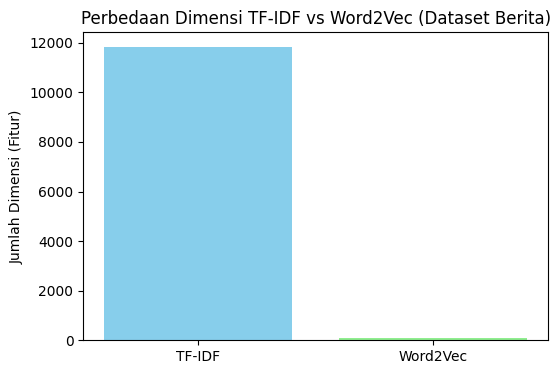

In [11]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Load dataset berita ---
# Use the already loaded DataFrame 'df'
# file_path = "CrawlBerita_Kesehatan-Pariwisata.csv"
# df = pd.read_csv(file_path)

# Use the correct column name 'isi_berita'
texts = df["isi_berita"].astype(str).tolist()

# --- 2. TF-IDF ---
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_dim = tfidf_matrix.shape[1]  # jumlah kata unik

# --- 3. Preprocessing Word2Vec ---
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

tokenized_texts = [clean_text(t).split() for t in texts]

# --- 4. Training Word2Vec ---
embedding_dim = 100  # dimensi tetap
w2v_model = Word2Vec(sentences=tokenized_texts, vector_size=embedding_dim, window=5, min_count=1, sg=1)

# --- 5. Hasil perbandingan ---
print("\n📊 Perbandingan Dimensi:")
print(f"- TF-IDF     : {tfidf_dim} dimensi (jumlah kata unik)")
print(f"- Word2Vec   : {embedding_dim} dimensi (tetap)")

# --- 6. Visualisasi ---
labels = ['TF-IDF', 'Word2Vec']
dims = [tfidf_dim, embedding_dim]

plt.figure(figsize=(6,4))
plt.bar(labels, dims, color=['skyblue','lightgreen'])
plt.title("Perbedaan Dimensi TF-IDF vs Word2Vec (Dataset Berita)")
plt.ylabel("Jumlah Dimensi (Fitur)")
plt.show()

## LDA BERITA

In [10]:
# 1. Import library
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
import nltk

# 2. Download stopwords Indonesia (sekali saja)
nltk.download('stopwords')
stop_words_ind = stopwords.words('indonesian')

# 3. Load file CSV
file_path = "/content/drive/MyDrive/PPW/berita_stemming_lemma.csv"
df = pd.read_csv(file_path, encoding='utf-8')

# 4. Pakai kolom hasil stemming
texts = df['isi_berita_stemming'].astype(str).tolist()

# 5. Buat representasi Bag of Words
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=stop_words_ind)
X = vectorizer.fit_transform(texts)

# 6. Buat model LDA
n_topics = 300  # jumlah topik
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda.fit(X)

# 7. Fungsi untuk tampilkan topik
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"\n📝 Topik {topic_idx+1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

no_top_words = 10
display_topics(lda, vectorizer.get_feature_names_out(), no_top_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(



📝 Topik 1:
zullies hamil harap hapus happy hantu hantam hanif hangat handuk

📝 Topik 2:
perut sakit kiri usus nyeri kondisi gejala kanker sembelit cerna

📝 Topik 3:
atlet otak orang cepat beda latih fungsi usia gera informasi

📝 Topik 4:
mbg anak racun gizi makan program gratis dr evaluasi ida

📝 Topik 5:
zullies hamil harap hapus happy hantu hantam hanif hangat handuk

📝 Topik 6:
zullies hamil harap hapus happy hantu hantam hanif hangat handuk

📝 Topik 7:
zullies hamil harap hapus happy hantu hantam hanif hangat handuk

📝 Topik 8:
zullies hamil harap hapus happy hantu hantam hanif hangat handuk

📝 Topik 9:
thailand pasang video viral hubung pantai turis seks polisi warga

📝 Topik 10:
zullies hamil harap hapus happy hantu hantam hanif hangat handuk

📝 Topik 11:
rusa biaya traveler gunung bal payung tingkat video pantai makan

📝 Topik 12:
motogp jalan tonton mataram mandalika parade barat lombok shuttle 2025

📝 Topik 13:
rokok larang spanyol langgar euro anak denda rp juta produk

📝 To